In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

REPO_ROOT = Path("").resolve()

# Adjust if you’re using a different alerts file
ALERTS_PATH = Path("/Users/jordanchambers/capstone_6019/out/r5.2/alerts_full/alerts.ndjson")
INSIDERS_PATH = Path("/Users/jordanchambers/capstone_6019/answers/insiders.csv")
print("ALERTS_PATH:", ALERTS_PATH.resolve())
print("INSIDERS_CSV:", INSIDERS_PATH.resolve())

ALERTS_PATH: /Users/jordanchambers/capstone_6019/out/r5.2/alerts_full/alerts.ndjson
INSIDERS_CSV: /Users/jordanchambers/capstone_6019/answers/insiders.csv


In [7]:
# ---- Load alerts from run_loop ----
alerts = pd.read_json(ALERTS_PATH, lines=True)

# Drop heartbeats
alerts = alerts[alerts["detector"] != "loop"].copy()

# Normalize types
alerts["user_key"] = alerts["user_key"].str.lower()
alerts["day"] = pd.to_datetime(alerts["day"]).dt.date

print("Alerts shape:", alerts.shape)
print("Detectors present:", sorted(alerts["detector"].unique()))
alerts.head()

Alerts shape: (78658, 10)
Detectors present: ['anomaly', 'forecast', 'ml', 'rules']


,day,user_key,detector,reason,score,evidence,human_summary,rules_score,anomaly_score,forecast_score
2,2010-01-04,emr0269,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
3,2010-01-04,vrp0267,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
5,2010-01-05,emr0269,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 3, 'usb_days_7d': 4, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
6,2010-01-05,ezb0925,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 1, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
7,2010-01-05,ocw1127,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN


In [9]:
# ---- Load Scenario-1 insiders ----
ins = pd.read_csv(INSIDERS_PATH)

s1 = ins[(ins["dataset"] == 5.2) & (ins["scenario"] == 1)].copy()

s1["user_key"] = s1["user"].str.lower()
s1["exfil_start"] = pd.to_datetime(
    s1["start"], format="%m/%d/%Y %H:%M:%S"
).dt.date

s1 = s1[["user_key", "exfil_start"]].drop_duplicates()

insider_users = set(s1["user_key"])

print("Scenario-1 insiders:", len(insider_users))
s1.head()

Scenario-1 insiders: 29


,user_key,exfil_start
82,alt1465,2010-08-13
83,alw0764,2011-02-03
84,ayg1697,2010-10-25
85,das1320,2010-07-09
86,dnj0740,2010-10-04


In [10]:
# Label alerts as insider / non-insider
alerts["is_insider"] = alerts["user_key"].isin(insider_users)

print("Total alerts:", len(alerts))
print("Alerts for insiders:", alerts["is_insider"].sum())
print("Unique users in alerts:", alerts["user_key"].nunique())

Total alerts: 78658
Alerts for insiders: 1045
Unique users in alerts: 1602


In [11]:
# ===== PRE-CHECK 1: per-detector user-level recall (S1 insiders) =====
def detector_user_recall(alerts: pd.DataFrame, insider_users: set[str]) -> pd.DataFrame:
    """For each detector: how many S1 insiders did it ever fire on?"""
    dets = sorted(alerts["detector"].unique())
    rows = []
    total_insiders = len(insider_users)

    for det in dets:
        df_det = alerts[alerts["detector"] == det]
        insider_hit_users = set(df_det[df_det["is_insider"]]["user_key"])
        rows.append({
            "detector": det,
            "insiders_hit": len(insider_hit_users),
            "total_insiders": total_insiders,
            "user_recall": len(insider_hit_users) / total_insiders if total_insiders else np.nan,
        })
    return pd.DataFrame(rows).sort_values("user_recall", ascending=False)

recall_df = detector_user_recall(alerts, insider_users)
recall_df

,detector,insiders_hit,total_insiders,user_recall
0,anomaly,29,29,1.000000
1,forecast,28,29,0.965517
2,ml,28,29,0.965517
3,rules,27,29,0.931034


In [13]:
# ===== PRE-CHECK 2: noise / false-positive stats =====
def detector_noise_stats(alerts: pd.DataFrame, insider_users: set[str]) -> pd.DataFrame:
    """For each detector, how noisy is it on non-insiders?"""
    all_users = set(alerts["user_key"])
    noninsider_users = all_users - insider_users
    total_noninsiders = len(noninsider_users)

    rows = []
    for det in sorted(alerts["detector"].unique()):
        df_det = alerts[alerts["detector"] == det].copy()
        df_non = df_det[~df_det["is_insider"]]

        non_users_flagged = set(df_non["user_key"])
        days = df_det["day"].nunique()

        rows.append({
            "detector": det,
            "noninsider_alerts": len(df_non),
            "noninsider_users_flagged": len(non_users_flagged),
            "total_noninsider_users": total_noninsiders,
            "user_FPR": len(non_users_flagged) / total_noninsiders if total_noninsiders else np.nan,
            "alerts_per_day": len(df_det) / days if days else np.nan,
        })
    return pd.DataFrame(rows).sort_values("user_FPR", ascending=False)

noise_df = detector_noise_stats(alerts, insider_users)
noise_df

,detector,noninsider_alerts,noninsider_users_flagged,total_noninsider_users,user_FPR,alerts_per_day
0,anomaly,75117,1542,1573,0.980292,148.160470
1,forecast,1976,282,1573,0.179275,5.530151
3,rules,520,79,1573,0.050223,4.443662
2,ml,0,0,1573,0.000000,1.333333


RULES  — users with any lead: 23
count    23.000000
mean      2.652174
std       3.625775
min       0.000000
25%       0.000000
50%       1.000000
75%       2.500000
max      14.000000
Name: lead_days, dtype: float64


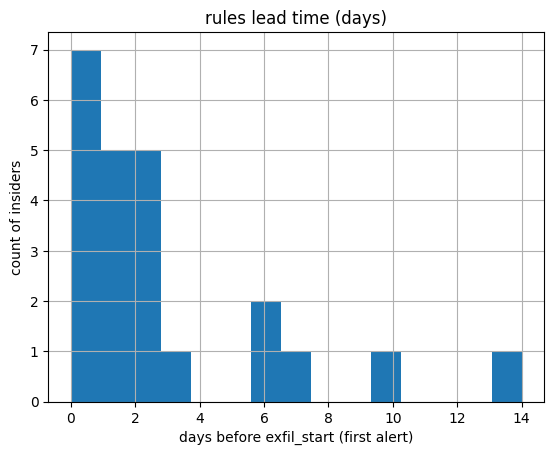

ML  — users with any lead: 24
count    24.000000
mean      0.750000
std       2.171956
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       8.000000
Name: lead_days, dtype: float64


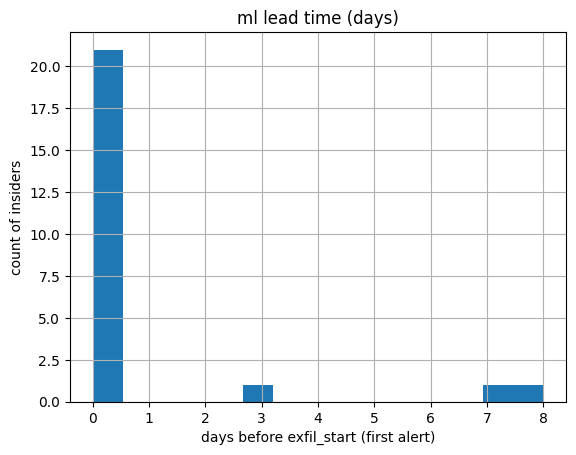

ANOMALY  — users with any lead: 28
count    28.000000
mean      7.428571
std      16.589663
min       0.000000
25%       1.000000
50%       2.000000
75%       3.750000
max      69.000000
Name: lead_days, dtype: float64


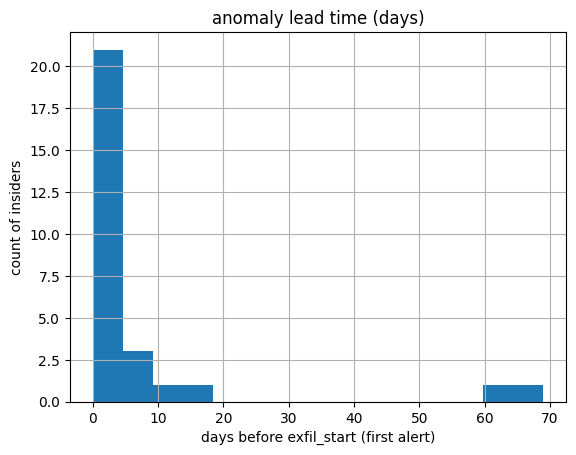

FORECAST  — users with any lead: 28
count     28.000000
mean      51.321429
std       91.310238
min        0.000000
25%        2.000000
50%        6.000000
75%       36.000000
max      341.000000
Name: lead_days, dtype: float64


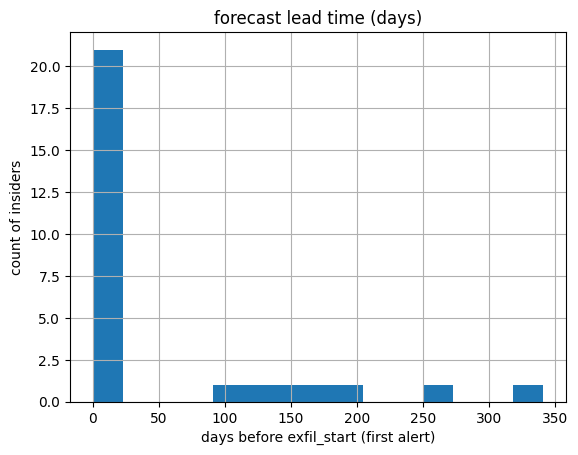

In [14]:
# ===== PRE-CHECK 3: lead-time per detector (S1)=====
def compute_lead_times(alerts: pd.DataFrame, exfil_df: pd.DataFrame, detector: str) -> pd.DataFrame:
    """
    For each S1 insider:
      earliest alert from this detector on/before exfil_start,
      compute exfil_start - first_alert in days.
    """
    df_det = alerts[alerts["detector"] == detector].copy()
    rows = []

    for _, row in exfil_df.iterrows():
        u = row["user_key"]
        exfil = row["exfil_start"]
        user_alerts = df_det[df_det["user_key"] == u]
        if user_alerts.empty:
            continue

        first_day = user_alerts["day"].min()
        if first_day > exfil:
            # Detector only fires after exfil, not helpful
            continue

        lead = (exfil - first_day).days
        rows.append({
            "user_key": u,
            "first_alert": first_day,
            "exfil_start": exfil,
            "lead_days": lead,
        })

    return pd.DataFrame(rows)

for det in ["rules", "ml", "anomaly", "forecast"]:
    lt = compute_lead_times(alerts, s1, det)
    print("=" * 60)
    print(det.upper(), " — users with any lead:", len(lt))
    if not lt.empty:
        print(lt["lead_days"].describe())
        # Optional quick histogram
        lt["lead_days"].hist(bins=15)
        plt.title(f"{det} lead time (days)")
        plt.xlabel("days before exfil_start (first alert)")
        plt.ylabel("count of insiders")
        plt.show()

In [15]:

# ===== PRE-CHECK 4: score separation insiders vs normals =====
def score_separation(alerts: pd.DataFrame, detector: str) -> pd.DataFrame | None:
    df = alerts[alerts["detector"] == detector].copy()
    if df.empty or "score" not in df.columns:
        return None
    out = df.groupby("is_insider")["score"].describe(
        percentiles=[0.25, 0.5, 0.75]
    )
    out.index = out.index.map({False: "non_insider", True: "insider"})
    return out

for det in sorted(alerts["detector"].unique()):
    print("=" * 80)
    print(det.upper())
    stats = score_separation(alerts, det)
    if stats is None:
        print("No score column available.")
    else:
        print(stats)

ANOMALY
               count      mean       std       min       25%       50%  \
is_insider                                                               
non_insider  75117.0  0.612863  0.137839  0.400015  0.511452  0.581597   
insider        593.0  0.870915  0.140716  0.413650  0.789678  0.916156   

                  75%  max  
is_insider                  
non_insider  0.709031  1.0  
insider      1.000000  1.0  
FORECAST
              count      mean       std       min       25%       50%  \
is_insider                                                              
non_insider  1976.0  0.626002  0.114764  0.500080  0.536253  0.588292   
insider       225.0  0.779581  0.151480  0.500355  0.639514  0.812174   

                  75%       max  
is_insider                       
non_insider  0.681925  0.949060  
insider      0.921358  0.987706  
ML
            count      mean       std       min       25%       50%      75%  \
is_insider                                                

In [18]:
# ===== PRE-CHECK 5: ensemble behavior =====
import sys
import os
from pathlib import Path

# Explicitly set repo root (you already know this is correct)
REPO_ROOT = Path("/Users/jordanchambers/capstone_6019")

# 1) Change working directory so "src/ui/static" resolves correctly
os.chdir(REPO_ROOT)
print("CWD:", Path.cwd())

# 2) Make sure repo root is on sys.path so `import src...` works
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Using REPO_ROOT:", REPO_ROOT)

from src.ui.app import normalize_alert

records = alerts.to_dict(orient="records")
norm = [normalize_alert(r) for r in records]

ens = pd.DataFrame(norm)
ens["day"] = pd.to_datetime(ens["day"]).dt.date
ens["is_insider"] = ens["user_key"].isin(insider_users)

print("Normalized alerts shape:", ens.shape)
ens.head()

CWD: /Users/jordanchambers/capstone_6019
Using REPO_ROOT: /Users/jordanchambers/capstone_6019
Normalized alerts shape: (78658, 13)


,alert_id,day,user_key,scenario_id,rule_hits,ml_score,anomaly_score,forecast_score,ensemble_score,escalated,ensemble_explanation,rule_human_summary,is_insider
0,13c27d07-38a8-40da-872f-d322350a1187,2010-01-04,emr0269,SCENARIO_1,[s1_near_miss],0.3,NaN,NaN,0.5,False,"{'ensemble_score': 0.5, 'escalated': False, 'r...",Possible preparation for data theft: after-hou...,False
1,6907b47b-5319-42e2-b5b9-7984d6387314,2010-01-04,vrp0267,SCENARIO_1,[s1_near_miss],0.3,NaN,NaN,0.5,False,"{'ensemble_score': 0.5, 'escalated': False, 'r...",Possible preparation for data theft: after-hou...,False
2,ee239eca-248f-4ceb-9e61-56475df2bdec,2010-01-05,emr0269,SCENARIO_1,[s1_near_miss],0.3,NaN,NaN,0.5,False,"{'ensemble_score': 0.5, 'escalated': False, 'r...",Possible preparation for data theft: after-hou...,False
3,fcc86736-b980-4ce5-ab81-5371bb5e1fdd,2010-01-05,ezb0925,SCENARIO_1,[s1_near_miss],0.3,NaN,NaN,0.5,False,"{'ensemble_score': 0.5, 'escalated': False, 'r...",Possible preparation for data theft: after-hou...,False
4,d98f6cc2-ce82-46f7-ae55-7f25e602bf97,2010-01-05,ocw1127,SCENARIO_1,[s1_near_miss],0.3,NaN,NaN,0.5,False,"{'ensemble_score': 0.5, 'escalated': False, 'r...",Possible preparation for data theft: after-hou...,False


In [19]:
def ensemble_user_recall(ens: pd.DataFrame, insider_users: set[str]) -> dict:
    df = ens[ens["escalated"]].copy()
    hit_users = set(df[df["is_insider"]]["user_key"])
    total_insiders = len(insider_users)

    all_users = set(ens["user_key"])
    noninsider_users = all_users - insider_users
    non_df = df[~df["is_insider"]]
    non_hit_users = set(non_df["user_key"])

    return {
        "insiders_hit": len(hit_users),
        "total_insiders": total_insiders,
        "insider_user_recall": len(hit_users) / total_insiders if total_insiders else np.nan,
        "noninsider_users_flagged": len(non_hit_users),
        "total_noninsider_users": len(noninsider_users),
        "noninsider_user_FPR": len(non_hit_users) / len(noninsider_users) if noninsider_users else np.nan,
    }

ensemble_stats = ensemble_user_recall(ens, insider_users)
ensemble_stats

{'insiders_hit': 29,
 'total_insiders': 29,
 'insider_user_recall': 1.0,
 'noninsider_users_flagged': 0,
 'total_noninsider_users': 1573,
 'noninsider_user_FPR': 0.0}

In [20]:
def ensemble_lead_times(ens: pd.DataFrame, exfil_df: pd.DataFrame) -> pd.DataFrame:
    df = ens[ens["escalated"]].copy()
    rows = []

    for _, row in exfil_df.iterrows():
        u = row["user_key"]
        exfil = row["exfil_start"]
        user_alerts = df[df["user_key"] == u]
        if user_alerts.empty:
            continue
        first_day = user_alerts["day"].min()
        if first_day > exfil:
            continue
        lead = (exfil - first_day).days
        rows.append({
            "user_key": u,
            "first_escalation": first_day,
            "exfil_start": exfil,
            "lead_days": lead,
        })
    return pd.DataFrame(rows)

ens_lt = ensemble_lead_times(ens, s1)
ens_lt.describe()

,lead_days
count,22.000000
mean,0.136364
std,0.639602
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,3.000000
